In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
from google.colab import files

uploaded = files.upload()

Saving flower.jpg to flower (2).jpg


Image loaded successfully!
Image file: flower (2).jpg


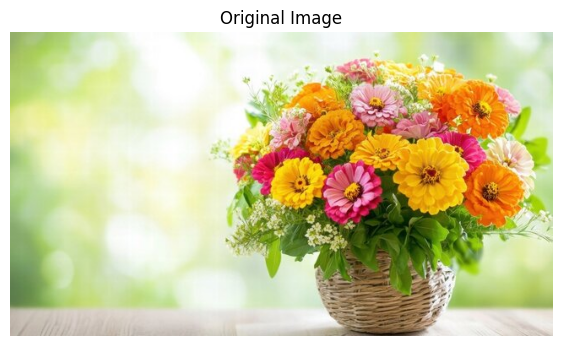

In [8]:
# Get the uploaded image filename
IMAGE_PATH = list(uploaded.keys())[0]

# Read the image using OpenCV
img = cv2.imread(IMAGE_PATH)

# Check if image was loaded successfully
if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image file:", IMAGE_PATH)

# Display image using Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [9]:
# Examine image properties

height, width, channels = img.shape

print("Image Properties")
print("-----------------")
print(f"Height: {height} pixels")
print(f"Width: {width} pixels")
print(f"Dimensions (H x W): {height} x {width}")
print(f"Number of channels: {channels}")
print(f"Data type: {img.dtype}")
print(f"Total pixels: {height * width}")
print(f"Total values: {img.size}")

Image Properties
-----------------
Height: 360 pixels
Width: 643 pixels
Dimensions (H x W): 360 x 643
Number of channels: 3
Data type: uint8
Total pixels: 231480
Total values: 694440


In [10]:
# Save image in JPEG and PNG formats

cv2.imwrite("output.jpg", img)
cv2.imwrite("output.png", img)

# Get file sizes
jpg_size = os.path.getsize("output.jpg")
png_size = os.path.getsize("output.png")

print("Image saved successfully!")
print(f"JPEG file size: {jpg_size} bytes")
print(f"PNG file size: {png_size} bytes")

# Compare file sizes
if jpg_size < png_size:
    print("JPEG file is smaller than PNG.")
elif png_size < jpg_size:
    print("PNG file is smaller than JPEG.")
else:
    print("Both files have the same size.")

Image saved successfully!
JPEG file size: 71865 bytes
PNG file size: 374225 bytes
JPEG file is smaller than PNG.


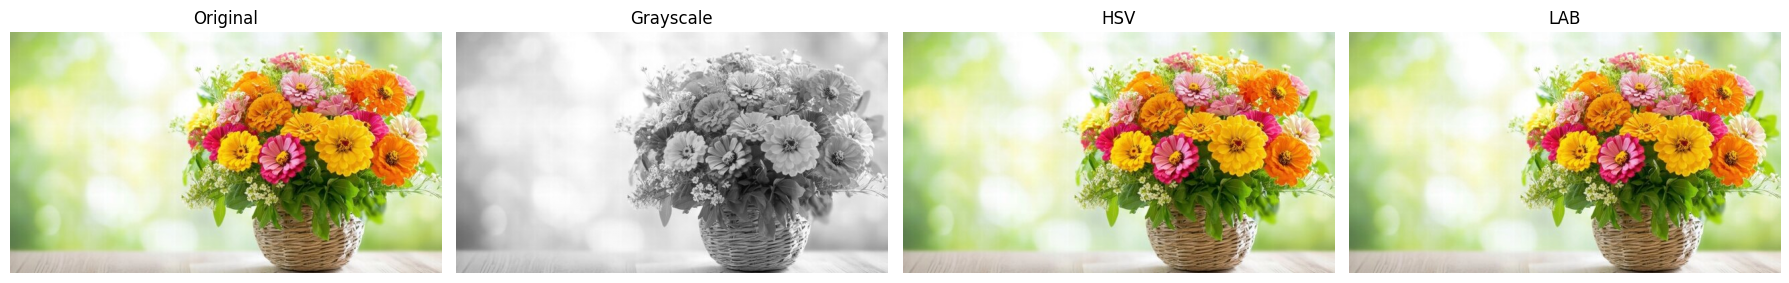

In [11]:
# Convert image to different color spaces

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Display all color spaces
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

# HSV and LAB need conversion to RGB for meaningful visualization
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
lab_rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

axes[2].imshow(hsv_rgb)
axes[2].set_title("HSV")
axes[2].axis("off")

axes[3].imshow(lab_rgb)
axes[3].set_title("LAB")
axes[3].axis("off")

plt.tight_layout()
plt.show()

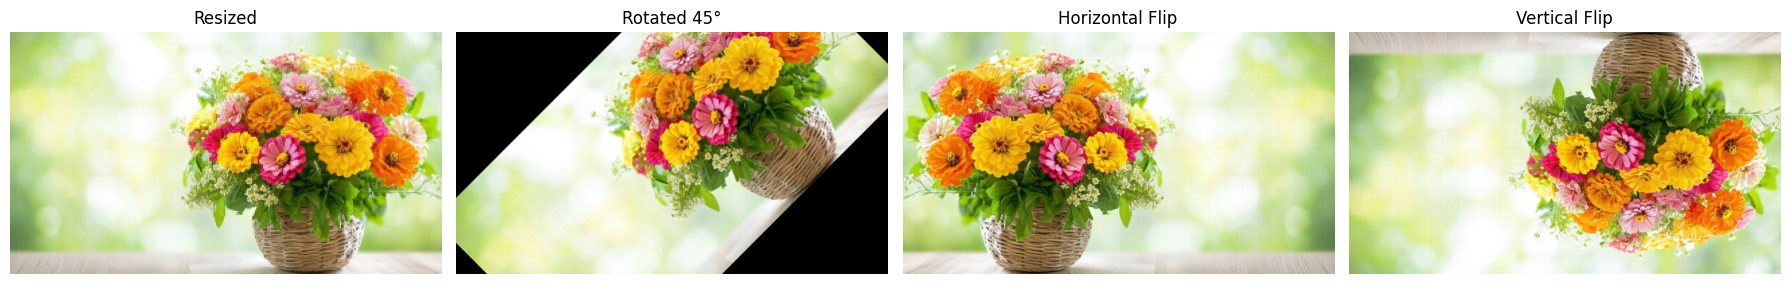

In [12]:
# Geometric transformations

# Resize image to half of its original dimensions
resized = cv2.resize(img, (width // 2, height // 2))

# Rotate image by 45 degrees
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, rotation_matrix, (width, height))

# Horizontal flip
flipped_h = cv2.flip(img, 1)

# Vertical flip
flipped_v = cv2.flip(img, 0)

# Display transformations
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0].set_title("Resized")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[1].set_title("Rotated 45°")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(flipped_h, cv2.COLOR_BGR2RGB))
axes[2].set_title("Horizontal Flip")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(flipped_v, cv2.COLOR_BGR2RGB))
axes[3].set_title("Vertical Flip")
axes[3].axis("off")

plt.tight_layout()
plt.show()

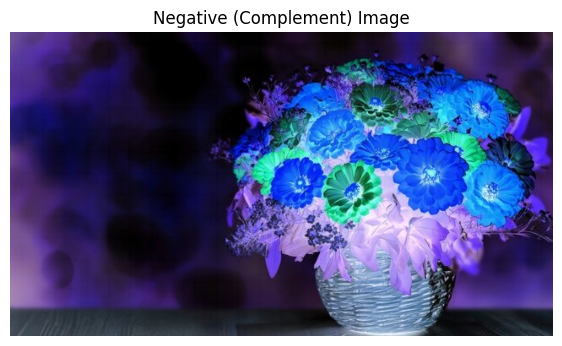

In [13]:
# Generate negative (complement) image

negative = 255 - img

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB))
plt.title("Negative (Complement) Image")
plt.axis("off")
plt.show()

ROI Properties
--------------
ROI shape: (180, 322, 3)
ROI height: 180 pixels
ROI width: 322 pixels
ROI mean pixel value (BGR): [113.75065562 167.77398206 192.62201518]


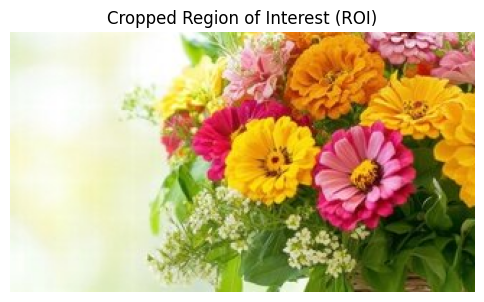

In [14]:
# Crop a Region of Interest (ROI)

x1 = width // 4
y1 = height // 4
x2 = 3 * width // 4
y2 = 3 * height // 4

roi = img[y1:y2, x1:x2]

# Analyze ROI properties
print("ROI Properties")
print("--------------")
print(f"ROI shape: {roi.shape}")
print(f"ROI height: {roi.shape[0]} pixels")
print(f"ROI width: {roi.shape[1]} pixels")

# Calculate mean pixel value
mean_pixel = roi.mean(axis=(0, 1))

print(f"ROI mean pixel value (BGR): {mean_pixel}")

# Display ROI
plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Cropped Region of Interest (ROI)")
plt.axis("off")
plt.show()

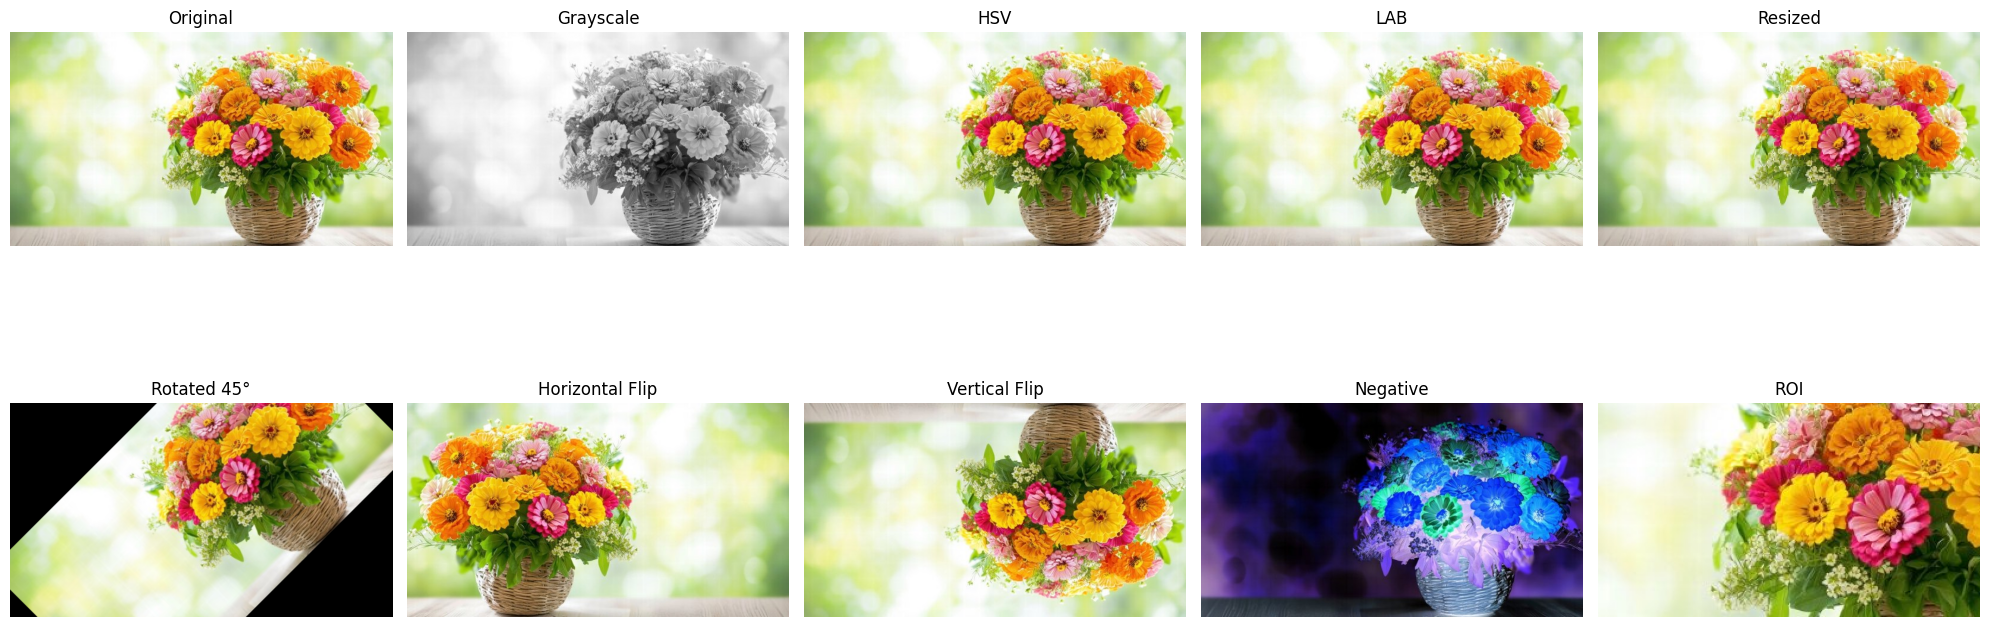

In [15]:
# Display original and processed images together

titles = [
    "Original",
    "Grayscale",
    "HSV",
    "LAB",
    "Resized",
    "Rotated 45°",
    "Horizontal Flip",
    "Vertical Flip",
    "Negative",
    "ROI"
]

images = [
    img_rgb,
    gray,
    hsv_rgb,
    lab_rgb,
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(flipped_h, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(flipped_v, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(negative, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
]

fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for ax, title, image in zip(axes.ravel(), titles, images):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Observations

print("OBSERVATIONS")
print("------------")

print("1. Grayscale conversion reduces the image to a single intensity channel,")
print("   removing color information while preserving important structural details.")

print("\n2. HSV color space separates hue, saturation, and value,")
print("   making it useful for color-based image segmentation.")

print("\n3. LAB color space separates lightness from color information,")
print("   making it useful for image enhancement and color analysis.")

print("\n4. Resizing changes the dimensions of the image, while rotation and flipping")
print("   change its geometric orientation.")

print("\n5. The negative image is produced by inverting pixel intensity values.")
print("   It can help highlight details in certain dark regions.")

print("\n6. Cropping an ROI isolates a selected region of the image,")
print("   which can reduce computational requirements for further analysis.")

print("\n7. These preprocessing techniques are important because they prepare")
print("   images for advanced computer vision tasks such as segmentation,")
print("   feature extraction, object detection, and image classification.")

OBSERVATIONS
------------
1. Grayscale conversion reduces the image to a single intensity channel,
   removing color information while preserving important structural details.

2. HSV color space separates hue, saturation, and value,
   making it useful for color-based image segmentation.

3. LAB color space separates lightness from color information,
   making it useful for image enhancement and color analysis.

4. Resizing changes the dimensions of the image, while rotation and flipping
   change its geometric orientation.

5. The negative image is produced by inverting pixel intensity values.
   It can help highlight details in certain dark regions.

6. Cropping an ROI isolates a selected region of the image,
   which can reduce computational requirements for further analysis.

7. These preprocessing techniques are important because they prepare
   images for advanced computer vision tasks such as segmentation,
   feature extraction, object detection, and image classification.


In [17]:
# Save processed images

cv2.imwrite("grayscale.jpg", gray)
cv2.imwrite("resized.jpg", resized)
cv2.imwrite("rotated.jpg", rotated)
cv2.imwrite("flipped_horizontal.jpg", flipped_h)
cv2.imwrite("flipped_vertical.jpg", flipped_v)
cv2.imwrite("negative.jpg", negative)
cv2.imwrite("roi.jpg", roi)

print("Processed images saved successfully!")

Processed images saved successfully!
